# 03 — Łączenie zbiorów + EDA

Połączenie generacji OZE z PSE (notebook 01) z pogodą z Open-Meteo Archive (notebook 02), dodanie cech czasowych, eksploracyjna analiza danych. Wynik: `data/processed/dataset_full.csv`.

Pełny opis projektu w README.

## 3.1 Wczytanie zbiorów

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = Path("data/processed")

pse = pd.read_csv(OUTPUT_DIR / "pse_oze_2023_2025.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")
pogoda = pd.read_csv(OUTPUT_DIR / "pogoda_2023_2025.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")

print(f"PSE:    {pse.shape}, zakres: {pse.index.min()} -> {pse.index.max()}")
print(f"Pogoda: {pogoda.shape}, zakres: {pogoda.index.min()} -> {pogoda.index.max()}")

PSE:    (26304, 2), zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00
Pogoda: (26304, 40), zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00


Dwa zbiory z poprzednich notebooków. PSE — generacja, pogoda — featury wejściowe.

## 3.2 Połączenie po timestampie

In [3]:
df = pd.concat([pogoda, pse], axis=1)

print(f"sklejony zbiór: {df.shape}")
print(f"NaN-y: {df.isna().sum().sum()}")
df.head()

sklejony zbiór: (26304, 42)
NaN-y: 0


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_sin_slupsk,wdir100_cos_slupsk,wdir100_sin_bydgoszcz,wdir100_cos_bydgoszcz,wdir100_sin_warszawa,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow,wi,pv
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,13.23,8.13,0.0,0.0,100,14.9,12.66,7.56,0.0,0.0,...,-0.891007,-0.453990,-0.838671,-0.544639,-0.809017,-0.587785,-0.891007,-0.453990,5529.188,0.0
2023-01-01 01:00:00,13.09,7.92,0.0,0.0,100,14.3,13.82,8.51,0.0,0.0,...,-0.788011,-0.615661,-0.857167,-0.515038,-0.809017,-0.587785,-0.809017,-0.587785,4250.700,0.0
2023-01-01 02:00:00,12.63,7.43,0.0,0.0,100,13.9,10.98,6.31,0.0,0.0,...,-0.788011,-0.615661,-0.848048,-0.529919,-0.882948,-0.469472,-0.707107,-0.707107,3124.613,0.0
2023-01-01 03:00:00,13.27,7.99,0.0,0.0,100,14.6,14.53,8.94,0.0,0.0,...,-0.829038,-0.559193,-0.819152,-0.573576,-0.838671,-0.544639,-0.707107,-0.707107,3486.663,0.0
2023-01-01 04:00:00,13.67,8.44,0.0,0.0,100,15.3,14.40,8.88,0.0,0.0,...,-0.829038,-0.559193,-0.891007,-0.453990,-0.809017,-0.587785,-0.743145,-0.669131,4257.800,0.0


Sklejone na wspólnym indeksie czasowym. Pogoda po lewej (40 kolumn), generacja po prawej (`wi`, `pv`).

## 3.3 Cechy czasowe

Godzina i dzień roku to zmienne cykliczne — godzina 23 i 0 są blisko siebie, podobnie 31 grudnia i 1 stycznia. Sieć neuronowa traktująca to liniowo nie zauważy tego cyklu, dlatego konwertujemy na sinus i cosinus.

In [4]:
hour = df.index.hour
doy = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["doy_sin"]  = np.sin(2 * np.pi * doy / 365.25)
df["doy_cos"]  = np.cos(2 * np.pi * doy / 365.25)

print(f"kolumn po dodaniu cech czasowych: {df.shape[1]}")
df[["hour_sin", "hour_cos", "doy_sin", "doy_cos"]].head()

kolumn po dodaniu cech czasowych: 46


,hour_sin,hour_cos,doy_sin,doy_cos
timestamp,,,,
2023-01-01 00:00:00,0.000000,1.000000,0.017202,0.999852
2023-01-01 01:00:00,0.258819,0.965926,0.017202,0.999852
2023-01-01 02:00:00,0.500000,0.866025,0.017202,0.999852
2023-01-01 03:00:00,0.707107,0.707107,0.017202,0.999852
2023-01-01 04:00:00,0.866025,0.500000,0.017202,0.999852


Z 42 kolumn (40 pogoda + 2 targety) zrobiło się 46 (dorzuciliśmy 4 cechy czasowe).

## 3.4 Rozkłady targetów

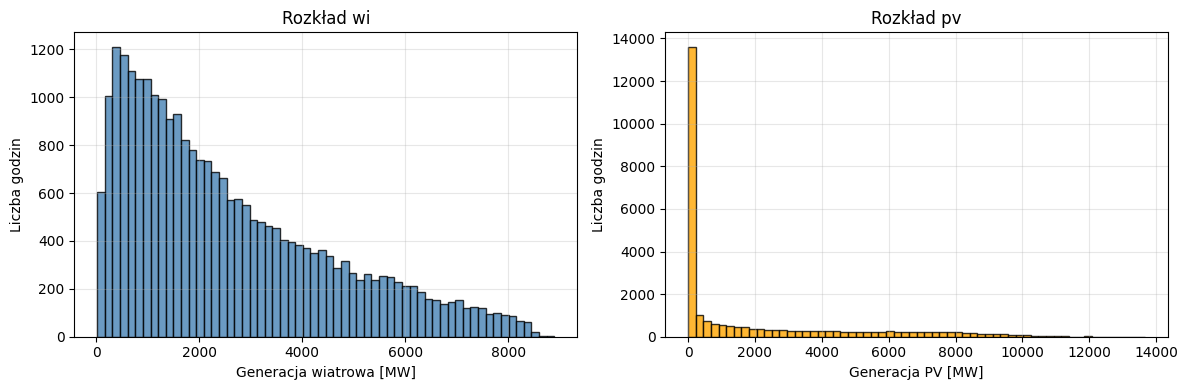

            wi       pv
count  26304.0  26304.0
mean    2578.1   1893.1
std     2005.4   2816.9
min       19.5      0.0
25%      960.4      0.0
50%     2032.1    146.4
75%     3800.1   3107.5
max     8894.6  13665.3


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["wi"], bins=60, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Generacja wiatrowa [MW]")
axes[0].set_ylabel("Liczba godzin")
axes[0].set_title("Rozkład wi")
axes[0].grid(alpha=0.3)

axes[1].hist(df["pv"], bins=60, color="orange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Generacja PV [MW]")
axes[1].set_ylabel("Liczba godzin")
axes[1].set_title("Rozkład pv")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df[["wi", "pv"]].describe().round(1))

`wi` ma rozkład skośny (długi ogon w prawo — rzadkie godziny silnego wiatru), `pv` ma duży pik przy zerze (noce, ~50% godzin) i rozkład zbliżony do wykładniczego dla godzin dziennych.

## 3.5 Sezonowość

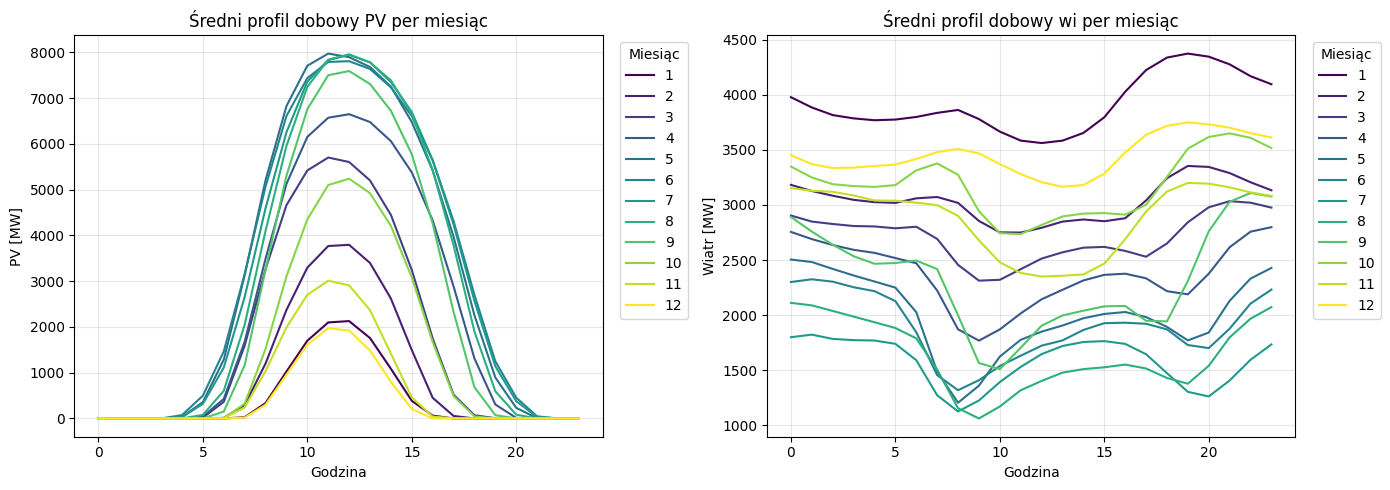

In [7]:
df_temp = df[["wi", "pv"]].copy()
df_temp["month"] = df_temp.index.month
df_temp["hour"] = df_temp.index.hour

profile_pv = df_temp.groupby(["month", "hour"])["pv"].mean().unstack(level=0)
profile_wi = df_temp.groupby(["month", "hour"])["wi"].mean().unstack(level=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
profile_pv.plot(ax=axes[0], colormap="viridis", lw=1.5)
axes[0].set_title("Średni profil dobowy PV per miesiąc")
axes[0].set_xlabel("Godzina")
axes[0].set_ylabel("PV [MW]")
axes[0].legend(title="Miesiąc", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].grid(alpha=0.3)

profile_wi.plot(ax=axes[1], colormap="viridis", lw=1.5)
axes[1].set_title("Średni profil dobowy wi per miesiąc")
axes[1].set_xlabel("Godzina")
axes[1].set_ylabel("Wiatr [MW]")
axes[1].legend(title="Miesiąc", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

PV: wyraźny cykl dobowy z szczytem w południe, latem szerszy łuk i wyższe wartości — silna sezonowość zarówno dobowa jak i roczna. Wiatr: cykl dobowy płaski (wiatr nie zna pory dnia), za to widoczna jest silna sezonowość roczna — zimą generacja niemal dwukrotnie wyższa niż latem, ze względu na bardziej dynamiczną atmosferę (silne wyże i niże).

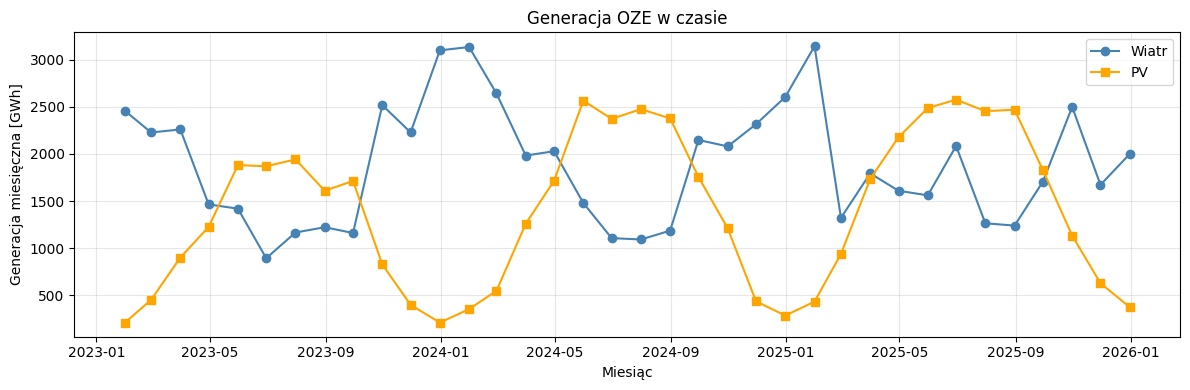

In [ ]:
monthly = df[["wi", "pv"]].resample("ME").sum() / 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly["wi"], color="steelblue", marker="o", label="Wiatr")
ax.plot(monthly.index, monthly["pv"], color="orange", marker="s", label="PV")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Generacja miesięczna [GWh]")
ax.set_title("Generacja OZE w czasie")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Wiatr ma sezonowość roczną odwrotną do PV — najwięcej w zimie (silne wyże/niże), najmniej w lecie. PV odwrotnie. Trend wzrostowy PV pokazuje rosnącą moc zainstalowaną w tych latach.

## 3.6 Korelacje pogoda → generacja

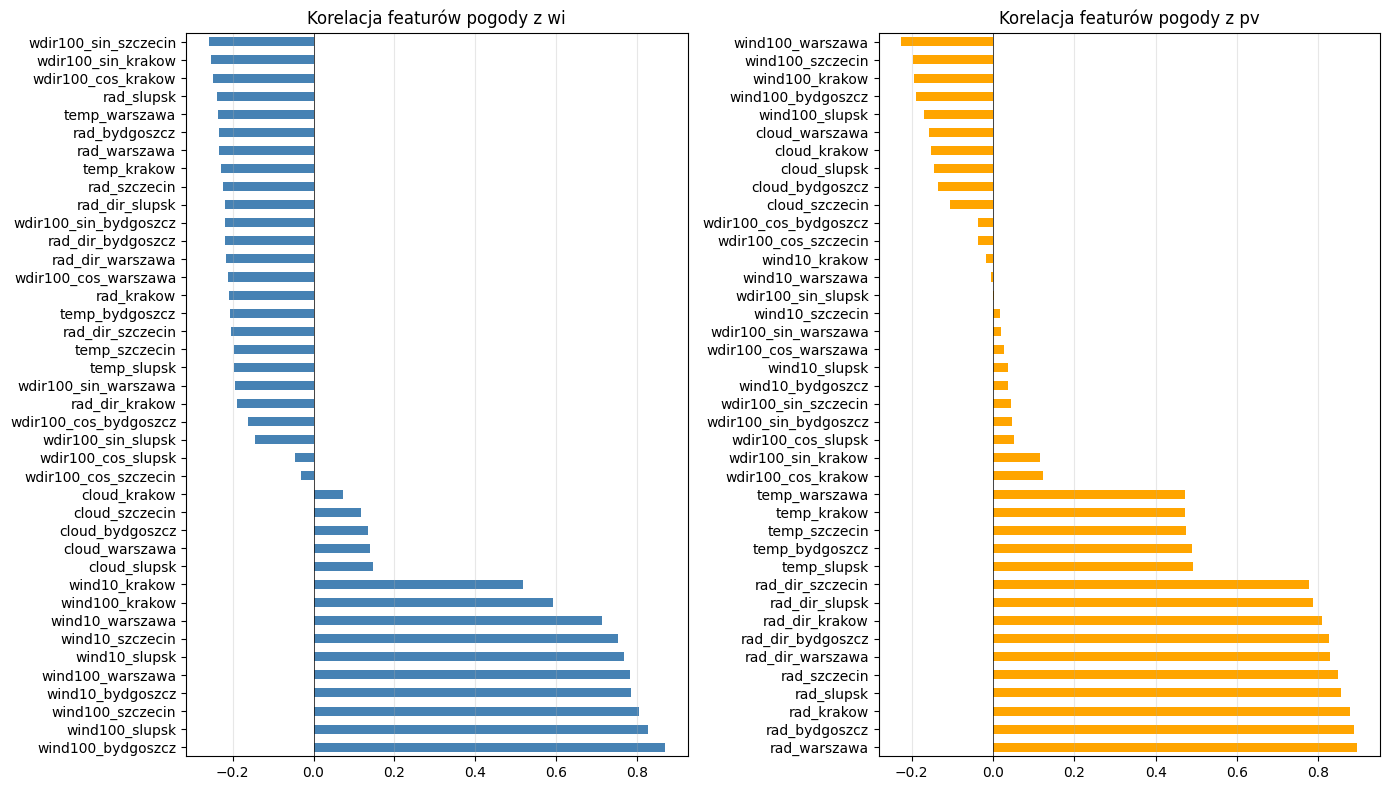

In [9]:
weather_cols = [c for c in df.columns if c not in ["wi", "pv", "hour_sin", "hour_cos", "doy_sin", "doy_cos"]]
corr_wi = df[weather_cols].corrwith(df["wi"]).sort_values(ascending=False)
corr_pv = df[weather_cols].corrwith(df["pv"]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
corr_wi.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Korelacja featurów pogody z wi")
axes[0].axvline(0, color="black", lw=0.5)
axes[0].grid(alpha=0.3, axis="x")

corr_pv.plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Korelacja featurów pogody z pv")
axes[1].axvline(0, color="black", lw=0.5)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

Najmocniejsze korelacje są zgodne z fizyką:
- `wind100_*` z `wi` — korelacje ~0.8 (prędkość wiatru na wysokości turbiny to bezpośredni predyktor generacji wiatrowej)
- `rad_*` z `pv` — korelacje ~0.85-0.9 (promieniowanie słoneczne to bezpośredni predyktor PV)

`cloud_cover` ma stosunkowo słabą korelację z `pv` (~-0.2), choć intuicja mówi inaczej. Wynika to z dwóch rzeczy: po pierwsze, `shortwave_radiation` już zawiera informację o zachmurzeniu (chmury redukują radiację), więc dwa featury mierzą ten sam efekt. Po drugie, nocą `cloud_cover` może być wysokie ale `pv = 0` niezależnie od chmur, co rozcieńcza korelację globalną. Sieć neuronowa sama ustali odpowiednie wagi, ewentualne redundancje są dla niej naturalne.

Korelacje ujemne wzajemne między featurami (np. `wind100_*` ujemne z `pv`) wynikają z sezonowości — zimą wiatr jest silniejszy, a radiacja niższa.

## 3.7 Outliery i wartości skrajne

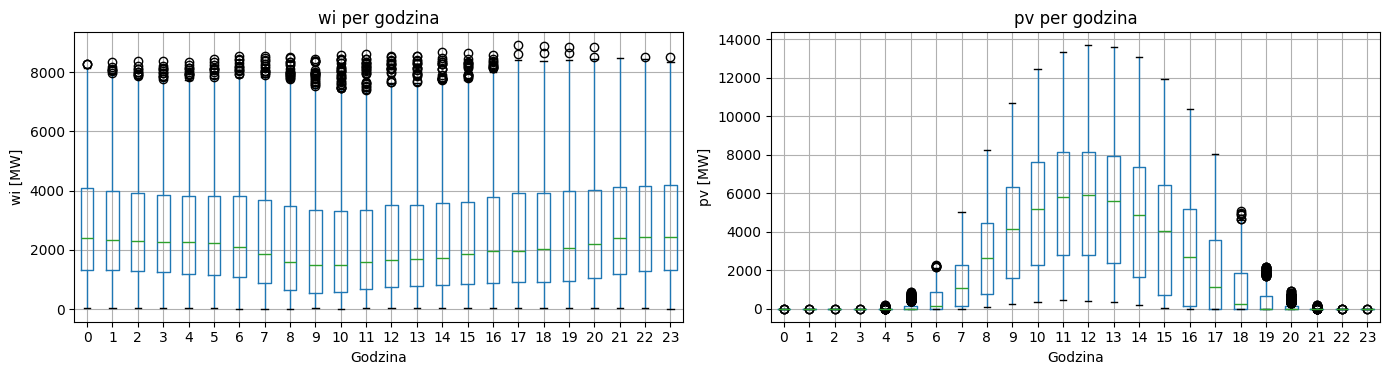

wi < 0: 0
pv < 0: 0
pv > 100 MW w nocy (godz. 23-3): 0


In [11]:
df_plot = df[["wi", "pv"]].copy()
df_plot["hour"] = df.index.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_plot.boxplot(column="wi", by="hour", ax=axes[0], showfliers=True)
axes[0].set_title("wi per godzina")
axes[0].set_xlabel("Godzina")
axes[0].set_ylabel("wi [MW]")

df_plot.boxplot(column="pv", by="hour", ax=axes[1], showfliers=True)
axes[1].set_title("pv per godzina")
axes[1].set_xlabel("Godzina")
axes[1].set_ylabel("pv [MW]")

plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"wi < 0: {(df['wi'] < 0).sum()}")
print(f"pv < 0: {(df['pv'] < 0).sum()}")
print(f"pv > 100 MW w nocy (godz. 23-3): {((df.index.hour.isin([23,0,1,2,3])) & (df['pv'] > 100)).sum()}")

Boxploty pokazują rozkład per godzinę. Outliery (kropki) to po prostu rzadkie godziny ekstremalnej generacji — fizycznie poprawne, nie usuwamy. Brak wartości ujemnych ani PV nocą — dane są czyste.

## 3.8 Kompletność

In [12]:
print(f"NaN-y w całym zbiorze: {df.isna().sum().sum()}")
expected = pd.date_range(df.index.min(), df.index.max(), freq="1h")
missing = expected.difference(df.index)
print(f"Brakujące godziny: {len(missing)}")
print(f"Wierszy: {len(df)}, kolumn: {df.shape[1]}")

NaN-y w całym zbiorze: 0
Brakujące godziny: 0
Wierszy: 26304, kolumn: 46


Zbiór jest kompletny — żadnych NaN, żadnych luk, 26 304 wiersze pokrywające 3 lata co godzinę.

## 3.9 Zapis finalnego zbioru

In [13]:
output_file = OUTPUT_DIR / "dataset_full.csv"
df.to_csv(output_file, sep=";", decimal=",")
print(f"zapisano: {output_file}")
print(f"wierszy: {len(df)}, kolumn: {df.shape[1]}")
df.describe().round(2)

zapisano: data/processed/dataset_full.csv
wierszy: 26304, kolumn: 46


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_sin_warszawa,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow,wi,pv,hour_sin,hour_cos,doy_sin,doy_cos
count,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,...,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00
mean,6.31,3.69,131.63,79.59,66.37,10.62,6.84,3.98,132.55,82.15,...,-0.21,-0.11,-0.22,-0.01,2578.07,1893.15,-0.00,-0.00,0.00,0.00
std,2.72,1.75,205.11,154.71,40.61,7.58,3.06,1.99,208.23,158.32,...,0.72,0.65,0.82,0.52,2005.44,2816.92,0.71,0.71,0.71,0.71
min,0.10,0.00,0.00,0.00,0.00,-9.90,0.05,0.00,0.00,0.00,...,-1.00,-1.00,-1.00,-1.00,19.50,0.00,-1.00,-1.00,-1.00,-1.00
25%,4.40,2.38,0.00,0.00,22.00,4.50,4.70,2.51,0.00,0.00,...,-0.92,-0.73,-0.97,-0.34,960.43,0.00,-0.71,-0.71,-0.70,-0.71
50%,6.19,3.46,5.00,0.00,96.00,10.30,6.55,3.67,5.00,0.00,...,-0.42,-0.16,-0.68,-0.03,2032.05,146.45,0.00,-0.00,-0.00,0.00
75%,8.00,4.74,196.00,75.00,100.00,16.50,8.67,5.14,196.00,80.00,...,0.50,0.45,0.80,0.33,3800.15,3107.52,0.71,0.71,0.71,0.71
max,18.93,12.30,879.00,771.00,100.00,32.20,22.07,12.77,864.00,755.00,...,1.00,1.00,1.00,1.00,8894.57,13665.25,1.00,1.00,1.00,1.00


## Podsumowanie sekcji 3

Finalny zbiór: **26 304 wiersze**, **46 kolumn** (40 pogoda + 2 targety + 4 cechy czasowe). Zakres 2023-01-01 → 2025-12-31, brak NaN-ów i luk czasowych. EDA potwierdziła fizyczną poprawność danych: prędkości wiatru najsilniej korelują z generacją wiatrową, radiacja z PV, sezonowość dobowa i roczna zgodne z oczekiwaniami.

Plik wynikowy: `data/processed/dataset_full.csv`.